# 1. Objetivo

Executar a **ANÁLISE PRINCIPAL** do estudo: estimar a associação entre IMC e FINDRISC na coorte única de pacientes com doenças autoimunes. Esta análise observacional de corte transversal usa apenas pares válidos e não permite interpretação causal.

# 2. Importações

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plots import plot_imc_findrisc, save_figure
from src.statistics import RANDOM_STATE, spearman_with_bootstrap_ci
from src.variables import (
    classificar_findrisc,
    classificar_imc,
    create_excesso_peso,
    create_findrisc_alto,
    create_obesidade,
)

# 3. Configuração

In [2]:
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'pacientes_clean.csv'
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'sociodemografico.csv'
TABLE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'table_3_imc_findrisc.csv'
FIGURE_PATH = PROJECT_ROOT / 'outputs' / 'figures' / 'figure_3_imc_findrisc.png'
N_BOOTSTRAP = 10_000
TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Python: {platform.python_version()}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'RANDOM_STATE: {RANDOM_STATE}')

Python: 3.14.6
pandas: 3.0.5
matplotlib: 3.11.1
RANDOM_STATE: 42


# 4. Carregamento

O carregamento usa uma lista fechada de variáveis necessárias à validação. Nenhuma identificação nominal é importada, exibida ou exportada.

In [3]:
required_columns = [
    'patient_id',
    'imc',
    'imc_categoria',
    'excesso_peso',
    'obesidade',
    'findrisc_score',
    'findrisc_categoria',
    'findrisc_alto',
]
df = pd.read_csv(PROCESSED_PATH, usecols=required_columns)
for column in ['excesso_peso', 'obesidade', 'findrisc_alto']:
    df[column] = df[column].astype('boolean')
print(f'Amostra analítica disponível: {len(df)} pacientes')
print('Dados carregados sem identificação nominal.')

Amostra analítica disponível: 75 pacientes
Dados carregados sem identificação nominal.


# 5. Validações

O controle de qualidade interrompe a análise se a anonimização, os tipos numéricos, as categorias recalculadas ou a preservação de missing falharem. Duplicatas e extremos já foram avaliados nos notebooks anteriores; nenhum valor válido é removido aqui.

In [4]:
assert df['patient_id'].notna().all() and df['patient_id'].is_unique
assert df['patient_id'].astype('string').str.fullmatch(r'P\d{3}').all()
assert pd.api.types.is_numeric_dtype(df['imc'])
assert pd.api.types.is_numeric_dtype(df['findrisc_score'])
pd.testing.assert_series_equal(
    df['imc_categoria'].astype('string'),
    df['imc'].apply(classificar_imc).astype('string'),
    check_names=False,
)
pd.testing.assert_series_equal(df['excesso_peso'], create_excesso_peso(df['imc']), check_names=False)
pd.testing.assert_series_equal(df['obesidade'], create_obesidade(df['imc']), check_names=False)
pd.testing.assert_series_equal(
    df['findrisc_categoria'].astype('string'),
    df['findrisc_score'].apply(classificar_findrisc).astype('string'),
    check_names=False,
)
pd.testing.assert_series_equal(
    df['findrisc_alto'], create_findrisc_alto(df['findrisc_score']), check_names=False
)
assert df.loc[df['imc'].isna(), ['excesso_peso', 'obesidade']].isna().all().all()
assert df.loc[df['findrisc_score'].isna(), 'findrisc_alto'].isna().all()

print('Controle de qualidade pré-análise: APROVADO')
print('[OK] registros vazios removidos e identificador interno único')
print('[OK] dataset anonimizado')
print('[OK] IMC e FINDRISC numéricos e categorias recalculadas')
print('[OK] missing preservado nas variáveis derivadas')
print('[OK] duplicatas e extremos previamente avaliados; nenhum valor excluído')

Controle de qualidade pré-análise: APROVADO
[OK] registros vazios removidos e identificador interno único
[OK] dataset anonimizado
[OK] IMC e FINDRISC numéricos e categorias recalculadas
[OK] missing preservado nas variáveis derivadas
[OK] duplicatas e extremos previamente avaliados; nenhum valor excluído


In [5]:
analysis_data = df[['imc', 'findrisc_score']].dropna().copy()
n_imc = int(df['imc'].notna().sum())
n_findrisc = int(df['findrisc_score'].notna().sum())
assert len(analysis_data) == 72
print(f'IMC válido: {n_imc}')
print(f'FINDRISC válido: {n_findrisc}')
print(f'N da análise principal: {len(analysis_data)}')

IMC válido: 73
FINDRISC válido: 74
N da análise principal: 72


# 6. Análise

A estatística principal é o rho de Spearman. O IC95% é obtido por bootstrap percentil pareado com 10.000 reamostragens e seed fixa 42. A estimativa, sua incerteza, o p-valor e o N são reportados conjuntamente.

In [6]:
result = spearman_with_bootstrap_ci(
    analysis_data['imc'],
    analysis_data['findrisc_score'],
    n_bootstrap=N_BOOTSTRAP,
    random_state=RANDOM_STATE,
)
result_table = pd.DataFrame([
    {
        'n': result['n'],
        'rho_spearman': result['rho'],
        'ic95_inferior': result['ic95_inferior'],
        'ic95_superior': result['ic95_superior'],
        'p_valor': result['p'],
        'metodo_ic': 'Bootstrap percentil pareado',
        'bootstrap': result['bootstrap'],
        'random_state': result['random_state'],
    }
])
result_table.to_csv(TABLE_PATH, index=False)

print('ANÁLISE PRINCIPAL')
print(f"N da análise principal: {result['n']}")
print(f"rho de Spearman: {result['rho']:.3f}".replace('.', ','))
print(
    f"IC95% bootstrap: {result['ic95_inferior']:.3f} a "
    f"{result['ic95_superior']:.3f}".replace('.', ',')
)
print(f"p-valor: {result['p']:.3e}".replace('.', ','))
print(f"Bootstrap: {result['bootstrap']:,} reamostragens; seed = {result['random_state']}".replace(',', '.'))
result_table

ANÁLISE PRINCIPAL
N da análise principal: 72
rho de Spearman: 0,704
IC95% bootstrap: 0,561 a 0,808
p-valor: 5,027e-12
Bootstrap: 10.000 reamostragens; seed = 42


,n,rho_spearman,ic95_inferior,ic95_superior,p_valor,metodo_ic,bootstrap,random_state
0,72,0.704457,0.561385,0.807711,5.026910e-12,Bootstrap percentil pareado,10000,42


# 7. Visualização

Cada ponto representa um paciente sem identificação individual. A linha LOWESS é apenas uma tendência visual; não representa um modelo causal nem substitui a correlação de Spearman.

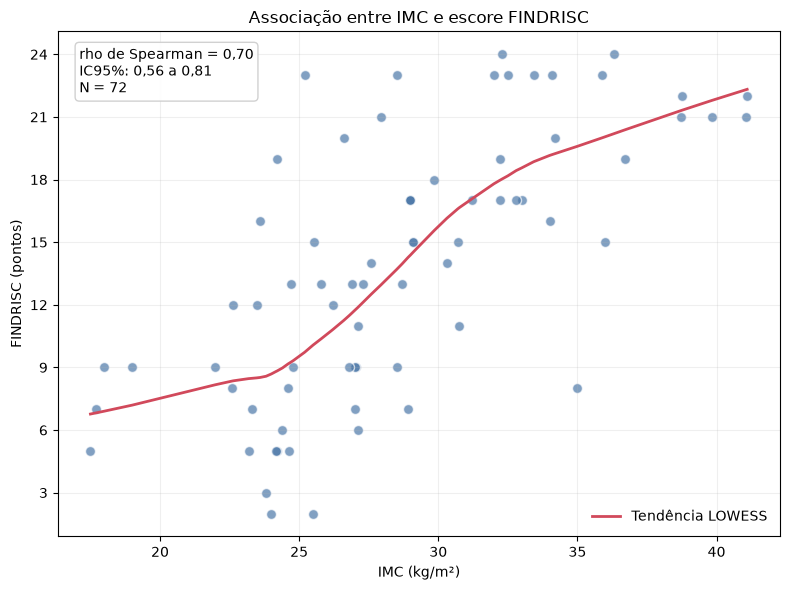

In [7]:
figure, _ = plot_imc_findrisc(
    analysis_data['imc'],
    analysis_data['findrisc_score'],
    rho=result['rho'],
    ic95_inferior=result['ic95_inferior'],
    ic95_superior=result['ic95_superior'],
)
save_figure(figure, FIGURE_PATH)
plt.show()

# 8. Conclusões deste notebook

A interpretação refere-se exclusivamente à amostra analisada e não implica causalidade.

**Limitação estrutural obrigatória:** O IMC é um dos componentes utilizados na construção do FINDRISC. Portanto, parte da associação observada é esperada pelo próprio desenho matemático do escore. As duas variáveis não devem ser tratadas como completamente independentes.

In [8]:
print('Maiores valores de IMC estiveram associados a maiores escores FINDRISC.')
print(
    'A magnitude observada foi positiva, mas a análise transversal não permite concluir causalidade.'
)
print(
    'O IMC é um dos componentes utilizados na construção do FINDRISC. Portanto, parte da associação '
    'observada é esperada pelo próprio desenho matemático do escore.'
)

Maiores valores de IMC estiveram associados a maiores escores FINDRISC.
A magnitude observada foi positiva, mas a análise transversal não permite concluir causalidade.
O IMC é um dos componentes utilizados na construção do FINDRISC. Portanto, parte da associação observada é esperada pelo próprio desenho matemático do escore.


# 9. Outputs gerados

O resultado agregado é salvo para reutilização no notebook final. A Figura 3 é exportada em PNG a 300 DPI. O arquivo bruto permanece inalterado.

In [9]:
assert TABLE_PATH.exists() and TABLE_PATH.stat().st_size > 0
assert FIGURE_PATH.exists() and FIGURE_PATH.stat().st_size > 0
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == (
    'a895b5340c856d2cd1772c8e115ed5efc20f409d3aef5ecba14da23d44da9bf4'
)
print('Outputs gerados:')
print(f'- {TABLE_PATH.relative_to(PROJECT_ROOT)}')
print(f'- {FIGURE_PATH.relative_to(PROJECT_ROOT)}')
print('Integridade do arquivo bruto confirmada por SHA-256.')

Outputs gerados:
- outputs/tables/table_3_imc_findrisc.csv
- outputs/figures/figure_3_imc_findrisc.png
Integridade do arquivo bruto confirmada por SHA-256.
